In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import math

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, f_regression, chi2
from sklearn.impute import SimpleImputer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             mean_squared_error, r2_score)


plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)
warnings.filterwarnings('ignore')
%matplotlib inline


## HELPER FUNCTIONS

In [2]:



def eda(df, target_col, task_type='Classification'):

    print(f"EDA for Target: {target_col}")

    plt.figure(figsize=(10, 4))
    sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
    plt.title("Missing Data Pattern (Heatmap)")
    plt.show()

    plt.figure(figsize=(8, 4))
    if task_type == 'Classification':
        sns.countplot(x=target_col, data=df, palette='viridis')
    else:
        sns.histplot(df[target_col], kde=True, color='teal')
    plt.title(f"Distribution of {target_col}")
    plt.show()

    numeric_df = df.select_dtypes(include=[np.number])
    if numeric_df.shape[1] > 1:
        plt.figure(figsize=(10, 8))
        sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
        plt.title("Feature Correlation Matrix")
        plt.show()

    plot_cols = [c for c in numeric_df.columns if c != target_col]

    if len(plot_cols) > 0:
        print("\n--- Outlier Detection (Box Plots Grid) ---")

        n_features = len(plot_cols)
        n_cols = 3
        n_rows = math.ceil(n_features / n_cols)

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
        axes = axes.flatten()

        for i, col in enumerate(plot_cols):
            sns.boxplot(x=df[col], ax=axes[i], color='skyblue')
            axes[i].set_title(f"Box Plot: {col}")
            axes[i].set_xlabel("")

        for j in range(i + 1, len(axes)):
            fig.delaxes(axes[j])

        plt.tight_layout()
        plt.show()

def evaluate_performance(model, X_test, y_test, task_type='Classification'):
    y_pred = model.predict(X_test)

    print("Model Performance")
    if task_type == 'Classification':
        print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
        print("\nClassification Report:\n", classification_report(y_test, y_pred))

        plt.figure(figsize=(6, 5))
        sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
        plt.title("Confusion Matrix")
        plt.xlabel("Predicted"); plt.ylabel("Actual")
        plt.show()
    else:
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        print(f"MSE: {mse:.4f} | R2 Score: {r2:.4f}")

        plt.figure(figsize=(8, 5))
        sns.scatterplot(x=y_test, y=y_test - y_pred, alpha=0.6)
        plt.axhline(0, color='red', linestyle='--')
        plt.title("Residual Plot)")
        plt.show()

## IRIS DATASET - CLASSIFICIATION

EDA for Target: Species


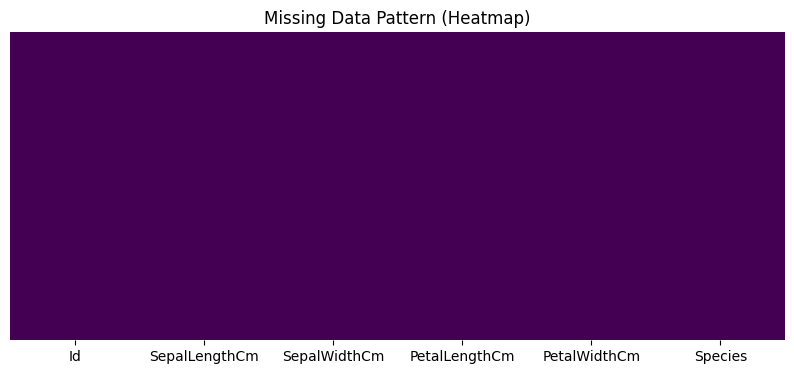

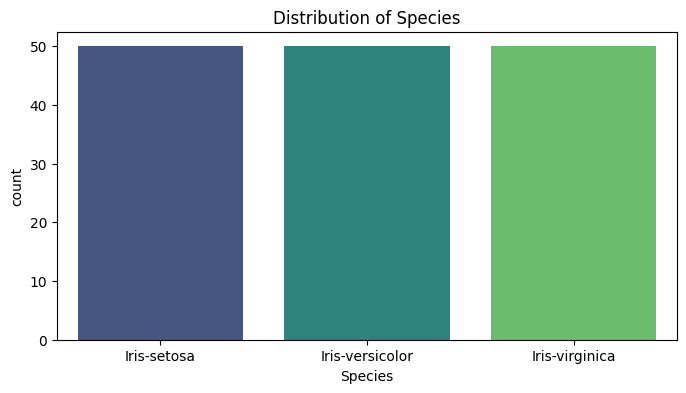

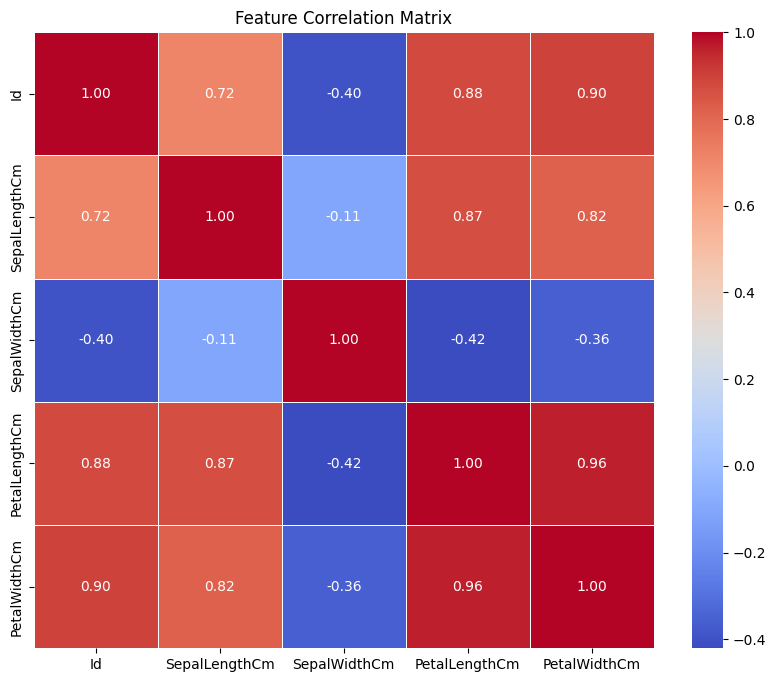


--- Outlier Detection (Box Plots Grid) ---


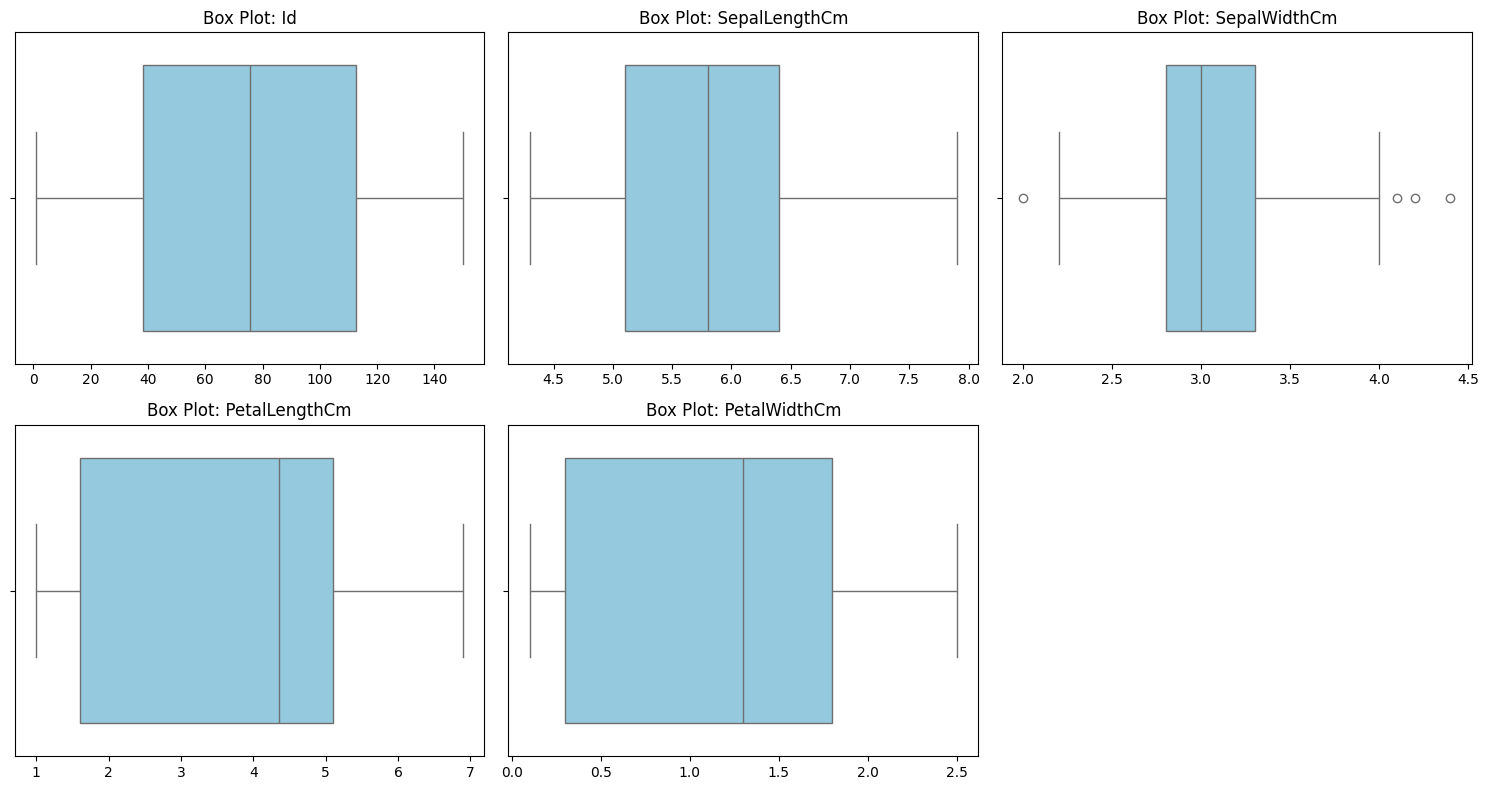

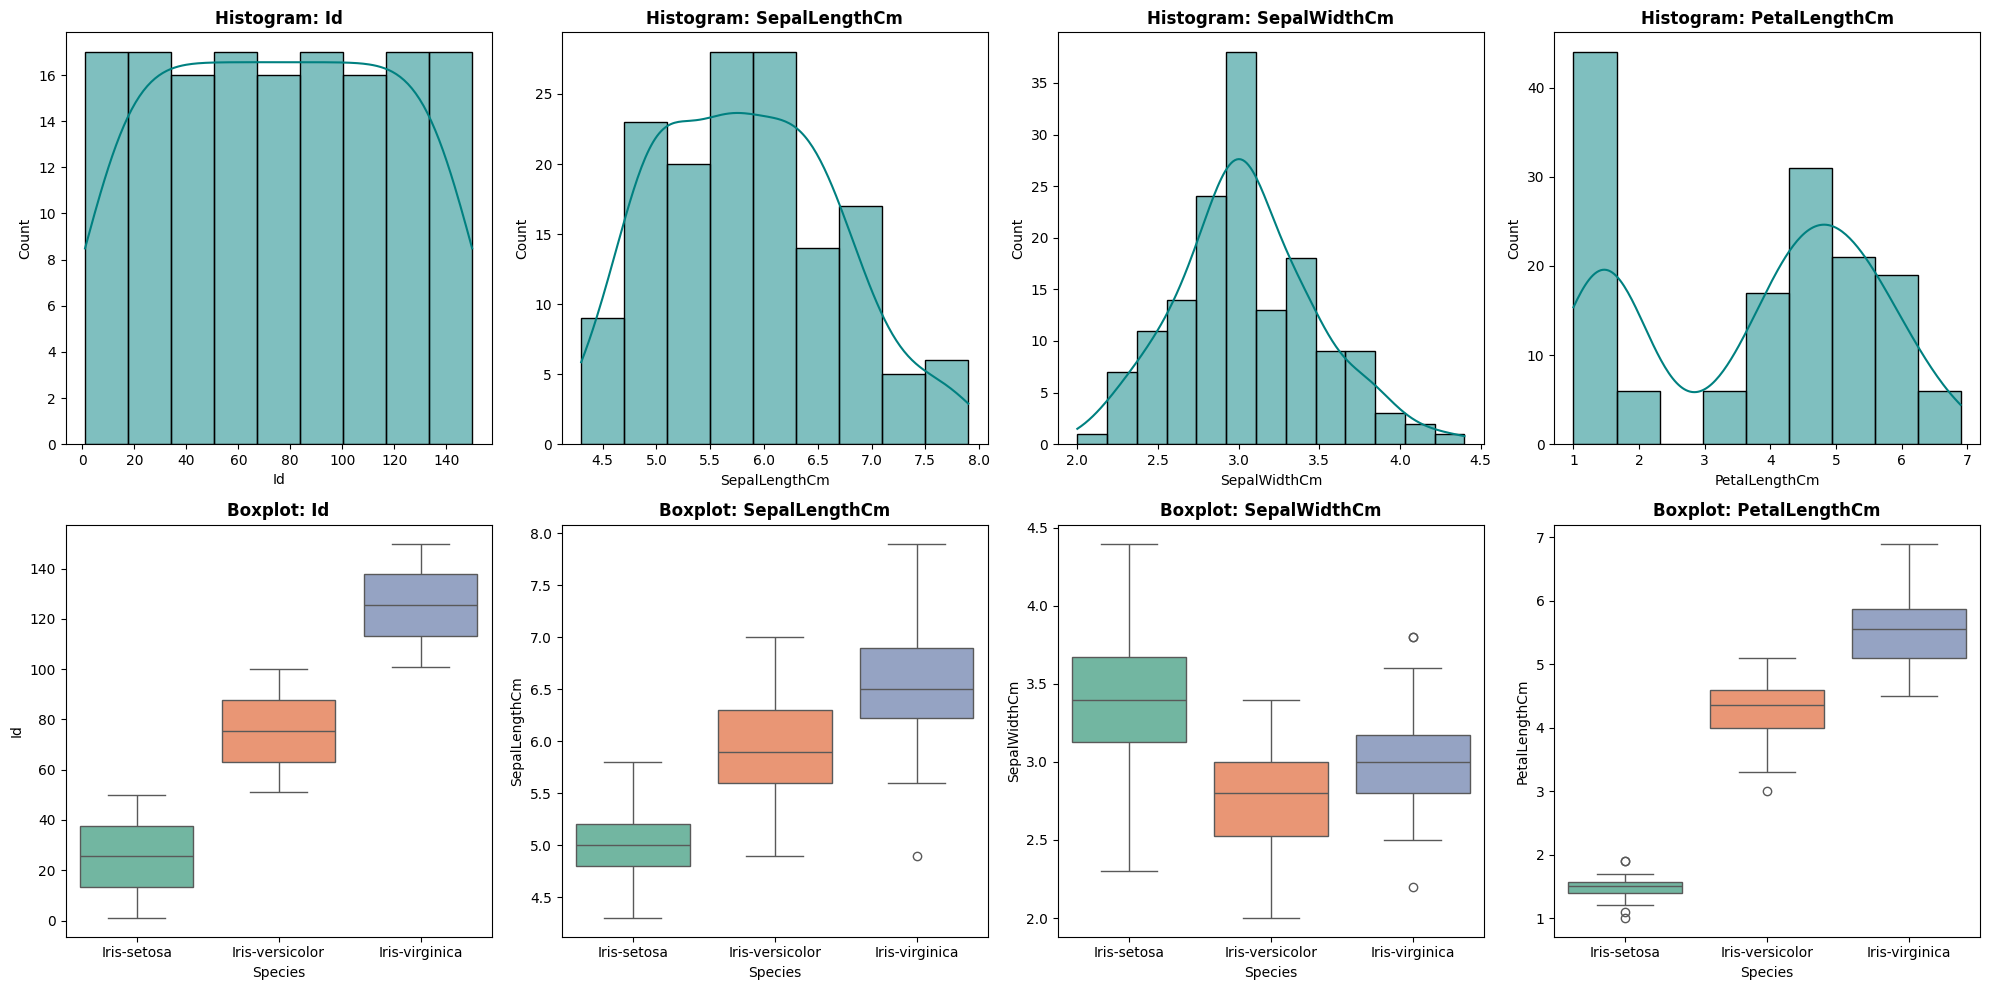

Model Performance
Accuracy: 1.0000

Classification Report:
                  precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



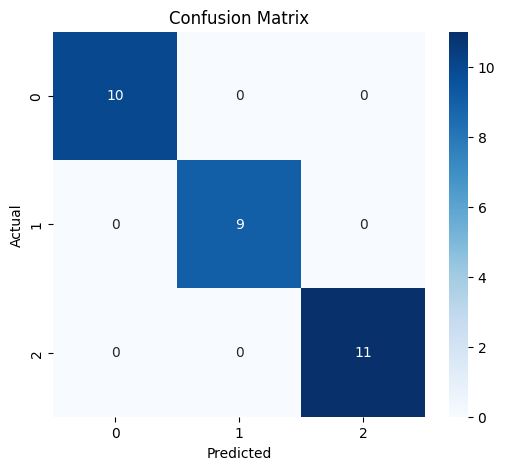

In [10]:
df_iris = pd.read_csv('Iris.csv')


target_col = 'Species' if 'Species' in df_iris.columns else 'species'

eda(df_iris, target_col)

X = df_iris.drop(target_col, axis=1)
y = df_iris[target_col]

selector = SelectKBest(score_func=f_classif, k='all')
X_selected = selector.fit_transform(X, y)

X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

features = df_iris.drop(target_col, axis=1).columns[:4]
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, col in enumerate(features):

    sns.histplot(df_iris[col], kde=True, ax=axes[0, i], color='teal')
    axes[0, i].set_title(f'Histogram: {col}', fontweight='bold')

    sns.boxplot(y=df_iris[col], x=df_iris[target_col], ax=axes[1, i], palette='Set2')
    axes[1, i].set_title(f'Boxplot: {col}', fontweight='bold')

plt.tight_layout()
plt.savefig('iris_hist_box.png', bbox_inches='tight', dpi=150)
plt.show()
model_iris = KNeighborsClassifier(n_neighbors=5)
model_iris.fit(X_train, y_train)

evaluate_performance(model_iris, X_test, y_test)

## Loan Prediction (Regression/Classification)

DATASET: LOAN STATUS
EDA for Target: loan_status


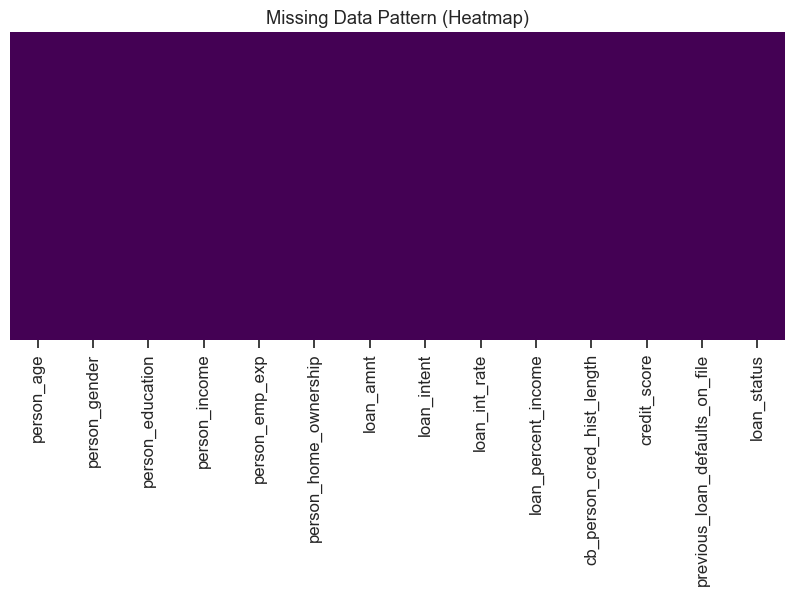

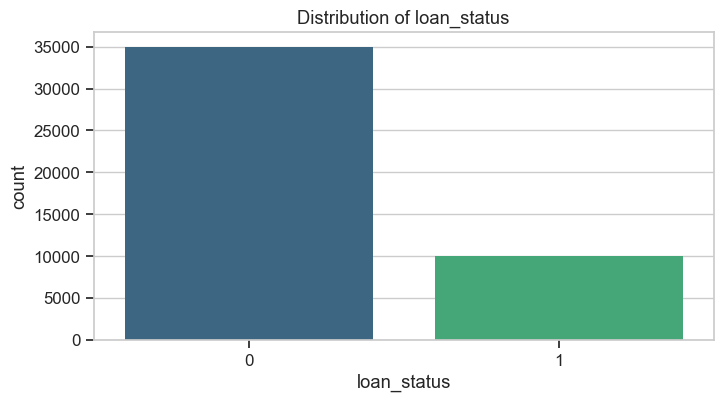

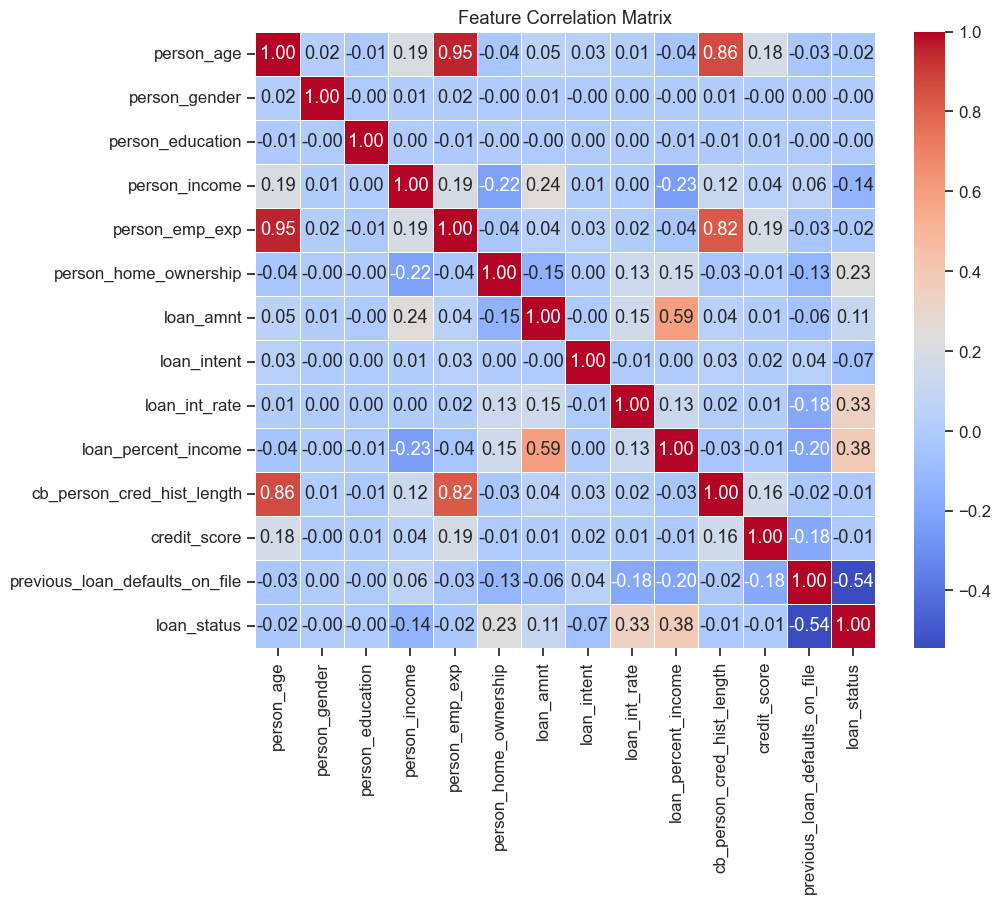


--- Outlier Detection (Box Plots Grid) ---


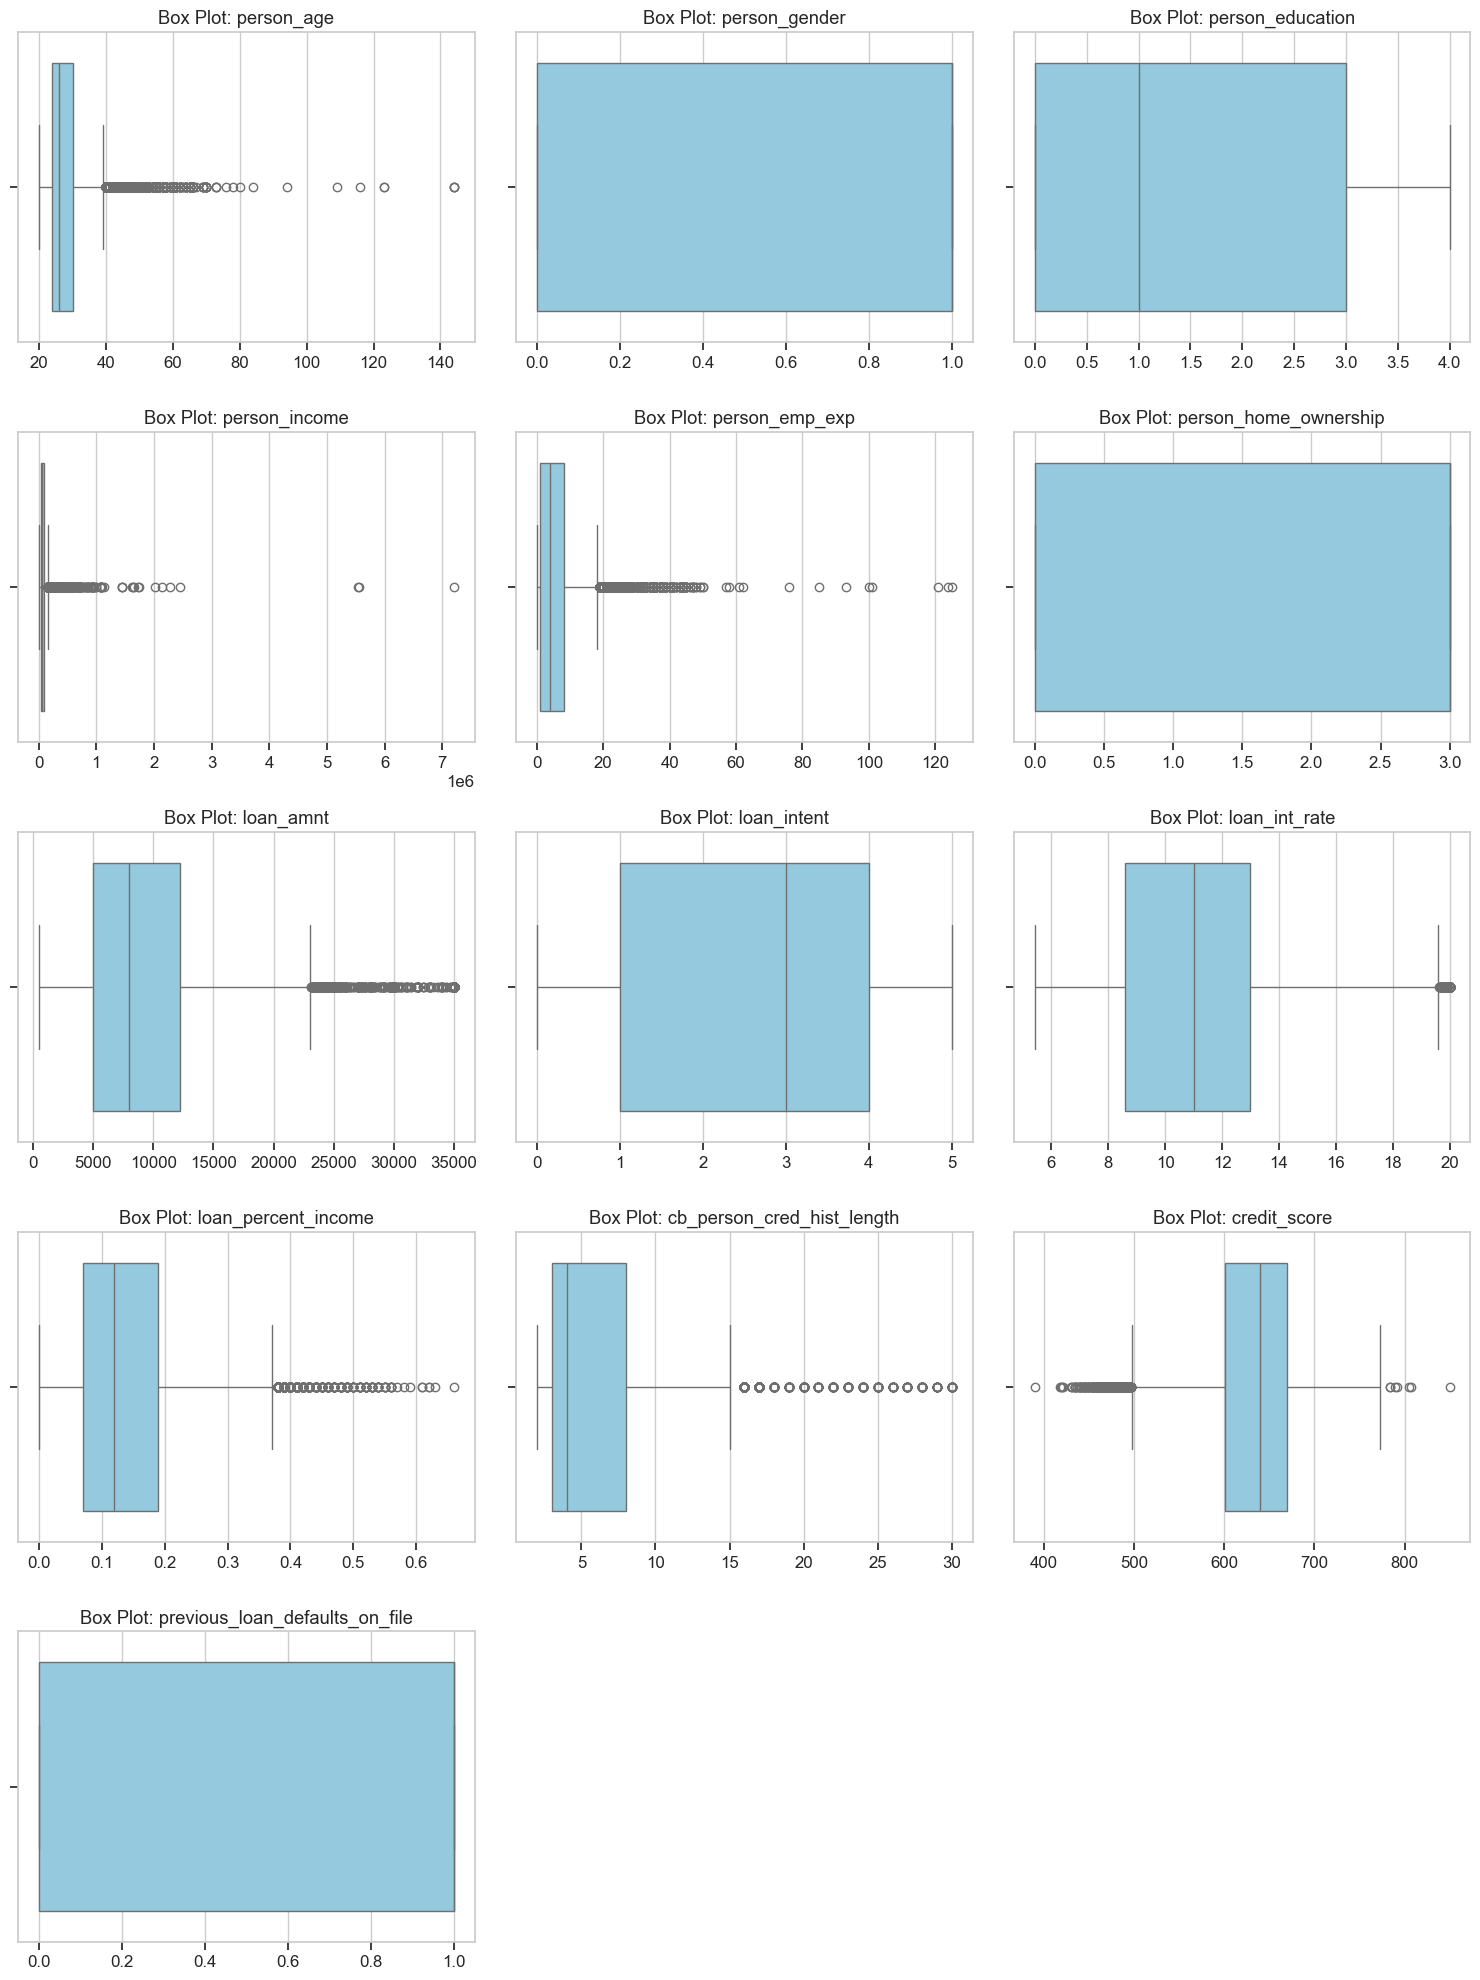

Model Performance
Accuracy: 0.9273

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.97      0.95      6990
           1       0.89      0.77      0.83      2010

    accuracy                           0.93      9000
   macro avg       0.91      0.87      0.89      9000
weighted avg       0.93      0.93      0.93      9000



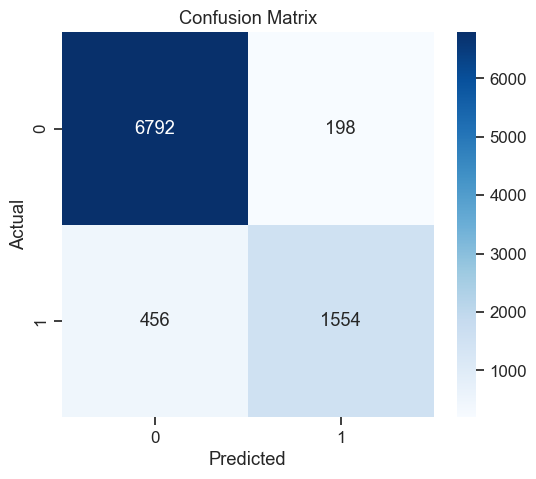

In [4]:

print("DATASET: LOAN STATUS")

df_loan = pd.read_csv('loan_data.csv')

df_loan.dropna(inplace=True)

target_col = 'loan_status'
X = df_loan.drop(target_col, axis=1)
y = df_loan[target_col]

cat_cols = ['person_gender', 'person_education', 'person_home_ownership',
            'loan_intent', 'previous_loan_defaults_on_file']
num_cols = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
            'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']

le = LabelEncoder()
for col in cat_cols:
    if col in X.columns:
        X[col] = le.fit_transform(X[col])

df_plot = X.copy()
df_plot[target_col] = y
eda(df_plot, target_col, task_type='Classification')

selector = SelectKBest(score_func=f_classif, k='all')
X_selected = selector.fit_transform(X, y)

X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model_loan = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model_loan.fit(X_train, y_train)

evaluate_performance(model_loan, X_test, y_test, task_type='Classification')

DATASET: DIABETES
EDA for Target: diabetes


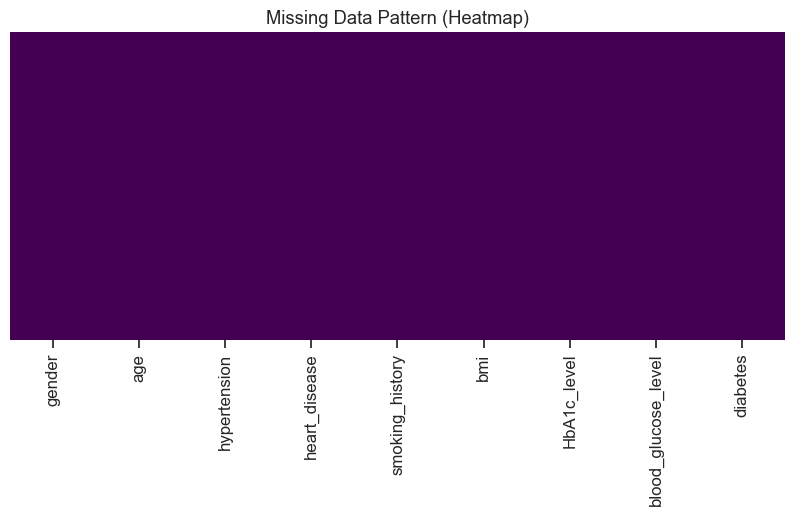

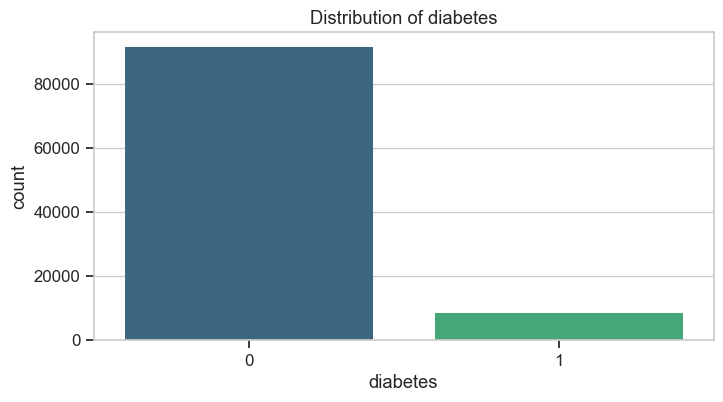

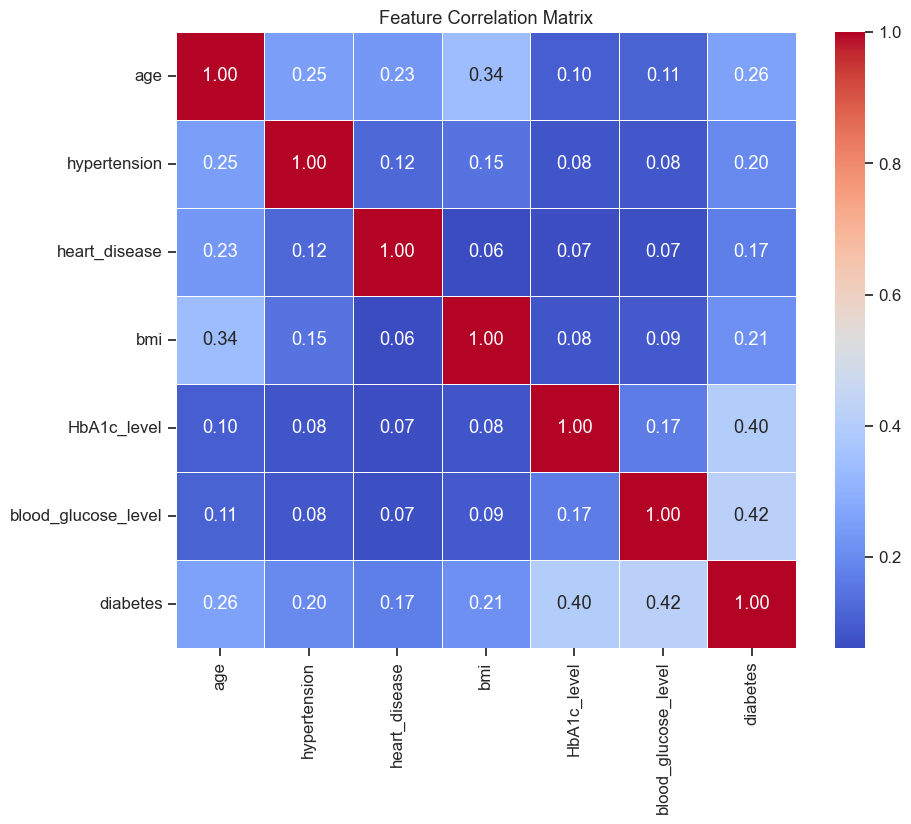


--- Outlier Detection (Box Plots Grid) ---


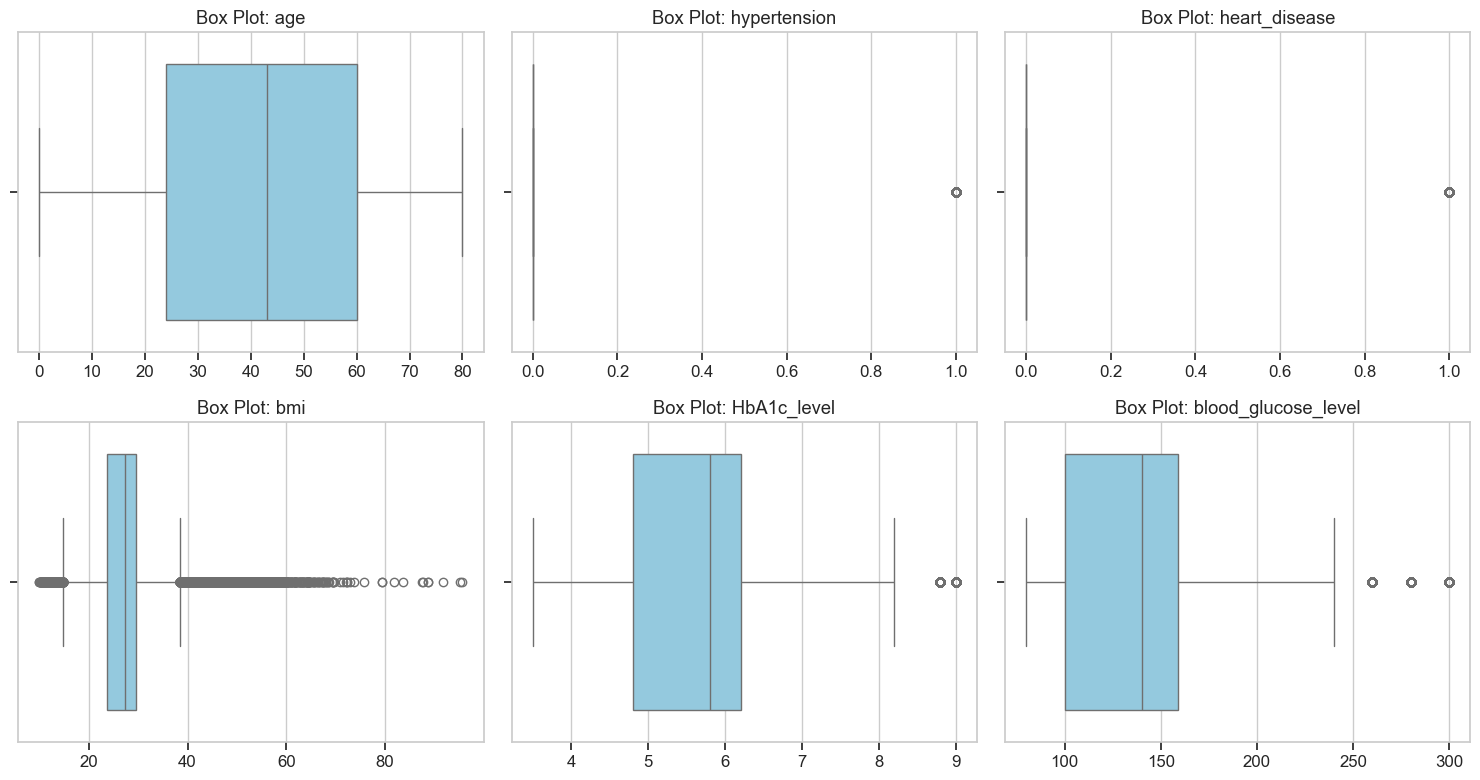

Encoding column 'gender' to numbers...
Encoding column 'smoking_history' to numbers...
Model Performance
Accuracy: 0.9587

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98     18292
           1       0.92      0.56      0.70      1708

    accuracy                           0.96     20000
   macro avg       0.94      0.78      0.84     20000
weighted avg       0.96      0.96      0.95     20000



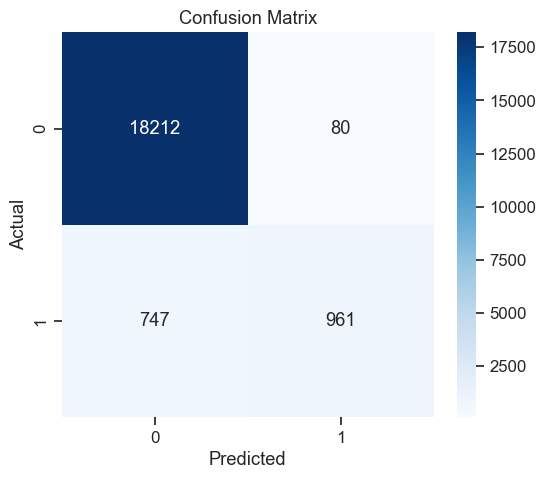

In [5]:

print("DATASET: DIABETES")

df_diabetes = pd.read_csv('diabetes.csv')

target = 'diabetes'

eda(df_diabetes, target, task_type='Classification')

X = df_diabetes.drop(target, axis=1)
y = df_diabetes[target]

le = LabelEncoder()
for col in X.columns:
    if X[col].dtype == 'object':
        print(f"Encoding column '{col}' to numbers...")
        X[col] = le.fit_transform(X[col])

if y.dtype == 'object':
    y = le.fit_transform(y)

selector = SelectKBest(score_func=chi2, k=5)
X_selected = selector.fit_transform(X, y)

X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

svc_model = SVC(kernel='linear', random_state=42)
svc_model.fit(X_train, y_train)

evaluate_performance(svc_model, X_test, y_test, task_type='Classification')

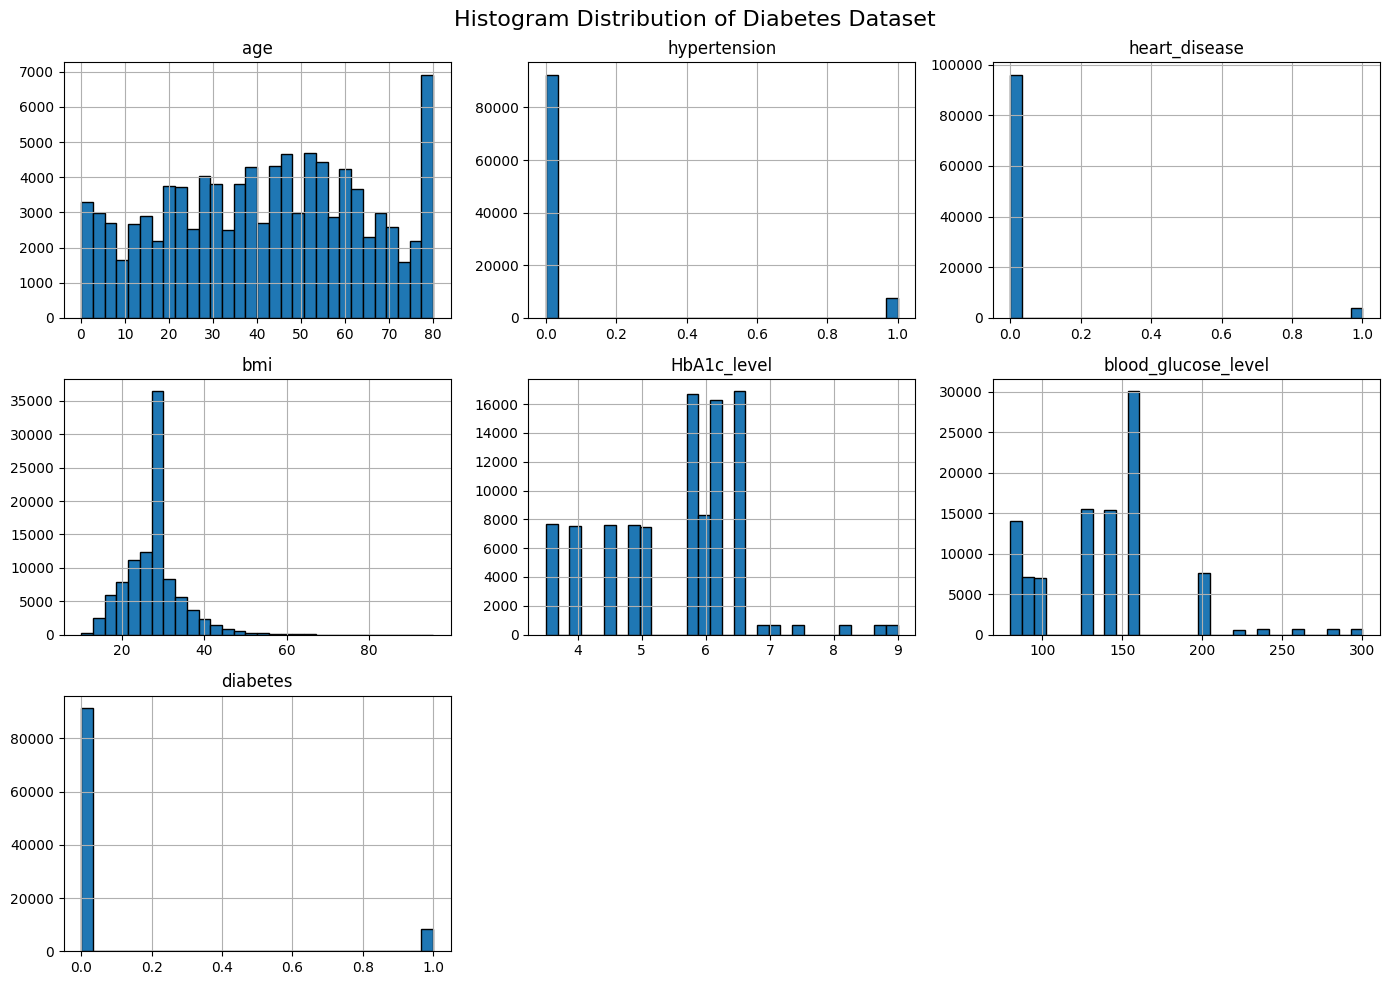

In [12]:
df_diabetes.hist(
    figsize=(14, 10),
    bins=30,
    edgecolor='black'
)

plt.suptitle("Histogram Distribution of Diabetes Dataset", fontsize=16)
plt.tight_layout()
plt.savefig("diabetes_histo.png")



 DATASET: SPAM/HAM EMAILS
EDA
EDA for Target: label


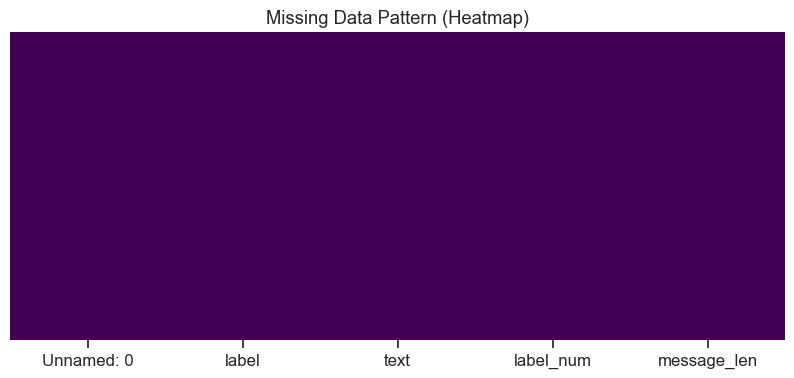

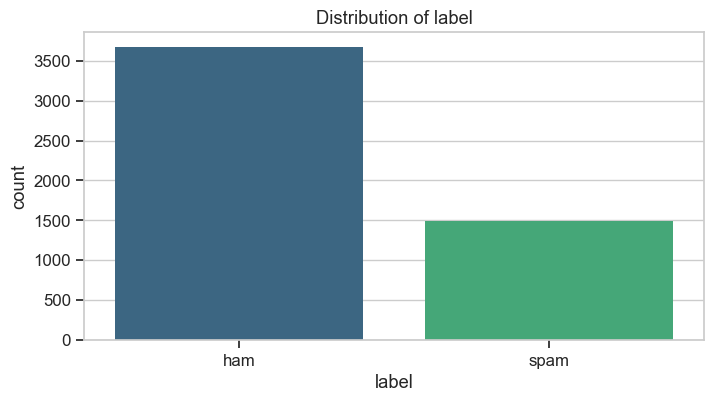

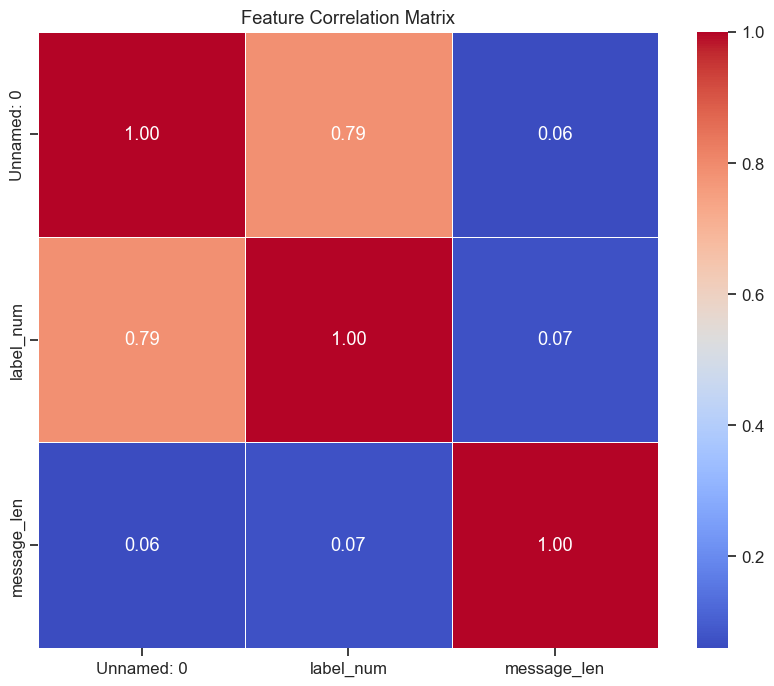


--- Outlier Detection (Box Plots Grid) ---


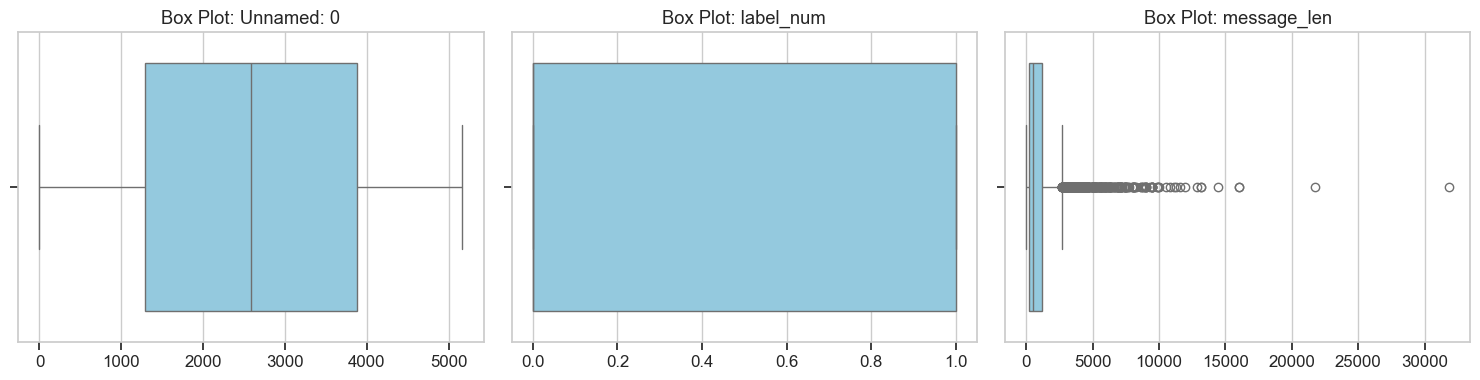

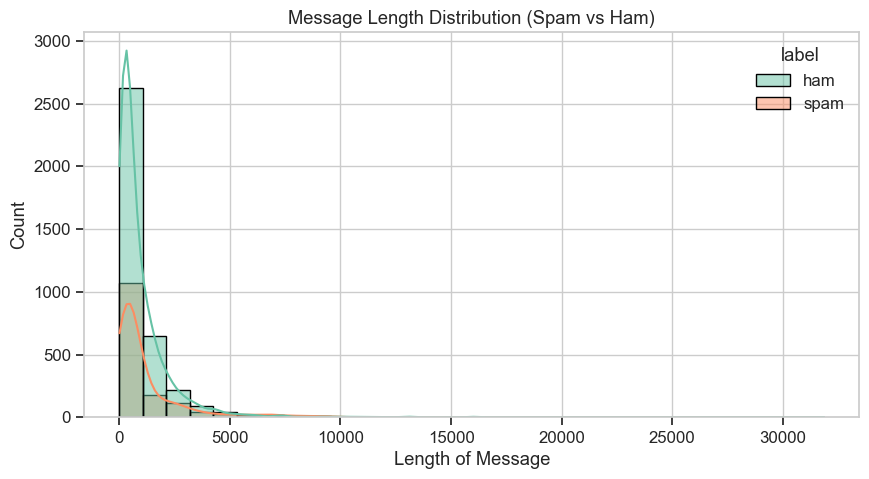

Model Performance
Accuracy: 0.9758

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98       742
           1       0.95      0.96      0.96       293

    accuracy                           0.98      1035
   macro avg       0.97      0.97      0.97      1035
weighted avg       0.98      0.98      0.98      1035



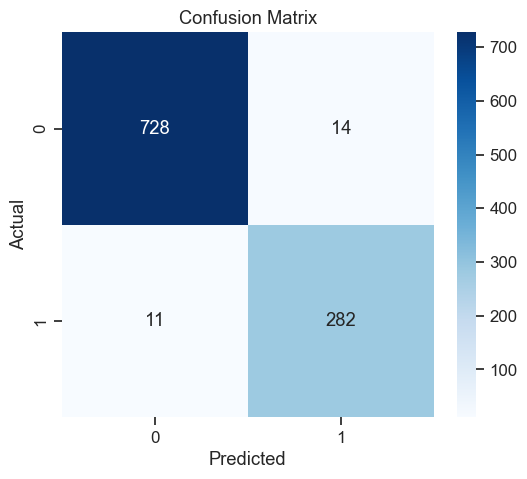

In [6]:
from sklearn.feature_extraction.text import CountVectorizer

print(" DATASET: SPAM/HAM EMAILS")

df_spam = pd.read_csv('spam_ham_dataset.csv')

df_spam['message_len'] = df_spam['text'].apply(lambda x: len(str(x)))

print(f"EDA")
eda(df_spam, 'label', task_type='Classification')

plt.figure(figsize=(10, 5))
sns.histplot(data=df_spam, x='message_len', hue='label', bins=30, kde=True, palette='Set2')
plt.title("Message Length Distribution (Spam vs Ham)")
plt.xlabel("Length of Message")
plt.show()

cv = CountVectorizer(stop_words='english')
X = cv.fit_transform(df_spam['text'].astype(str))
y = df_spam['label_num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

evaluate_performance(nb_model, X_test, y_test, task_type='Classification')


Sample Images


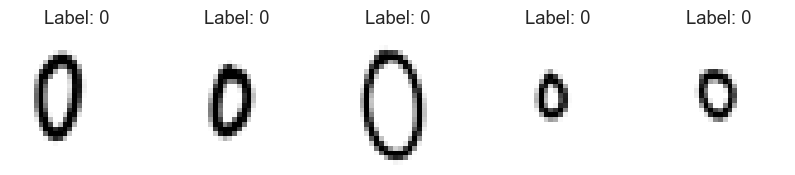

Model Performance
Accuracy: 0.4443

Classification Report:
               precision    recall  f1-score   support

           0       0.25      0.27      0.26        11
           1       0.30      0.58      0.40        12
           2       0.40      0.50      0.44         8
           3       0.73      0.50      0.59        16
           4       0.36      0.42      0.38        12
           5       0.50      0.25      0.33        12
           6       0.50      0.46      0.48        13
           7       0.64      0.60      0.62        15
           8       0.11      0.11      0.11         9
           9       0.29      0.42      0.34        12
           A       0.50      0.70      0.58        10
           B       0.62      0.36      0.45        14
           C       0.50      0.91      0.65        11
           D       0.36      0.56      0.43         9
           E       0.56      0.45      0.50        11
           F       0.60      0.60      0.60        15
           G       0.

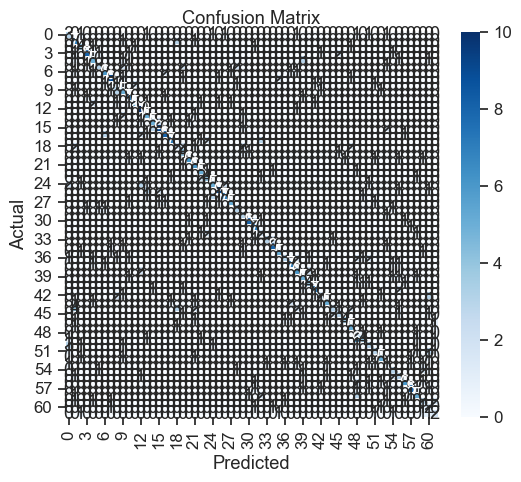

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier

df_csv = pd.read_csv('mnist_labels.csv')

def load_custom_images(df, target_size=(28, 28)):

    data = []
    for path in df['image']:
        img = Image.open(path).convert('L').resize(target_size)
        data.append(np.array(img).flatten())
    return np.array(data)

X = load_custom_images(df_csv)
y = df_csv['label'].values

df_digits = pd.DataFrame(X)
df_digits['target'] = y

print("Sample Images")
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
for i, ax in enumerate(axes):
    if i < len(X):
        ax.imshow(X[i].reshape(28, 28), cmap='gray')
        ax.set_title(f"Label: {y[i]}")
        ax.axis('off')
plt.show()


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

rf_mnist = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_mnist.fit(X_train, y_train)

evaluate_performance(rf_mnist, X_test, y_test)

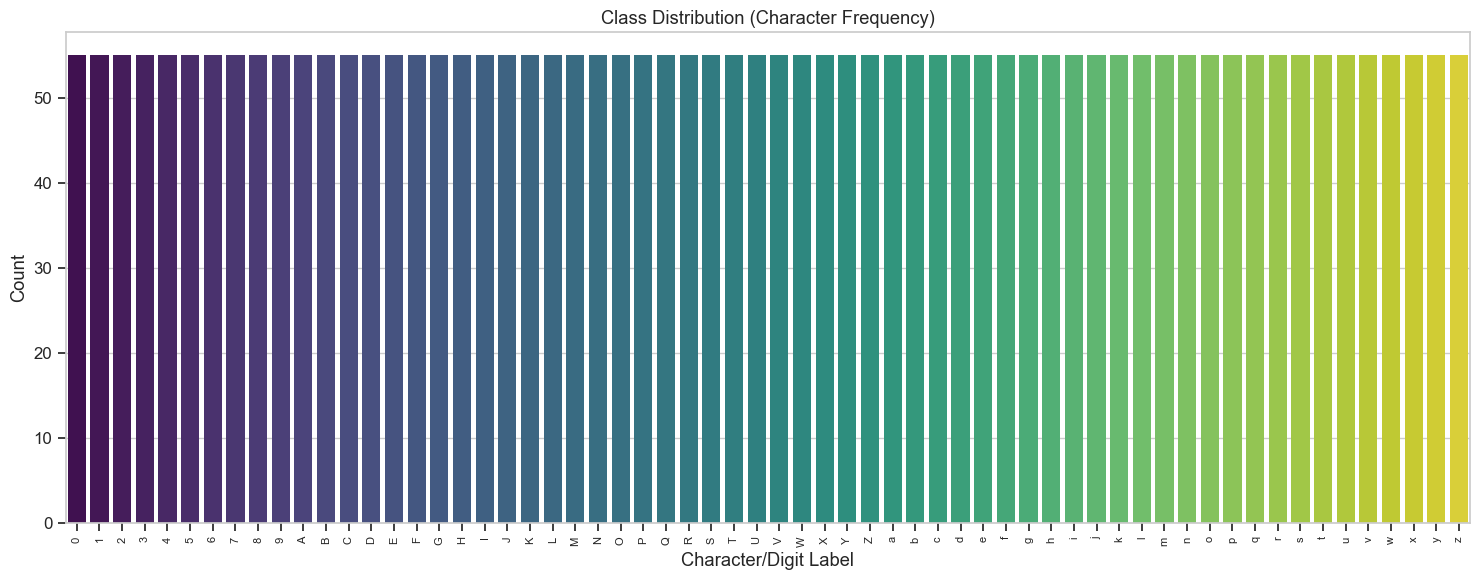

Saved: mnist_distribution.png


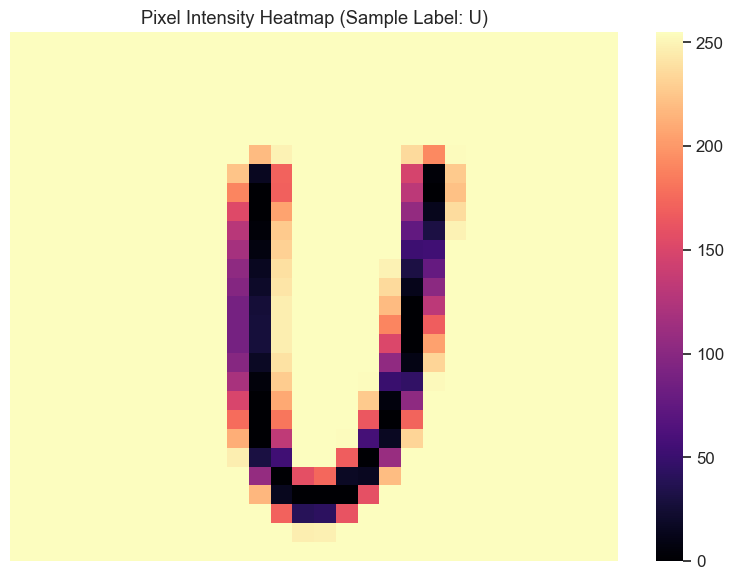

Saved: mnist_heatmap.png


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(15, 6))  # Wide figure to fit 62 classes

sorted_labels = sorted(df_csv['label'].unique().astype(str))

sns.countplot(x='label', data=df_csv, order=sorted_labels, palette='viridis')

plt.title("Class Distribution (Character Frequency)")
plt.xlabel("Character/Digit Label")
plt.ylabel("Count")
plt.xticks(rotation=90, fontsize=8)  # Rotate labels vertical to fit all 62
plt.tight_layout()

plt.savefig('mnist_distribution.png', bbox_inches='tight')
plt.show()
print("Saved: mnist_distribution.png")


plt.figure(figsize=(8, 6))

idx = np.random.randint(0, len(X))


img_matrix = X[idx].reshape(28, 28)
label = y[idx]

sns.heatmap(img_matrix, cmap='magma', annot=False, cbar=True)

plt.title(f"Pixel Intensity Heatmap (Sample Label: {label})")
plt.axis('off')
plt.tight_layout()

plt.savefig('mnist_heatmap.png', bbox_inches='tight')
plt.show()
print("Saved: mnist_heatmap.png")

In [9]:

results = {
    "Dataset": ["Iris", "Loan Amount", "Diabetes", "Email Spam", "MNIST"],
    "Task Type": ["Classification", "Regression", "Classification", "Classification", "Classification"],
    "Feature Selection": ["ANOVA (SelectKBest)", "Correlation", "Chi-Square", "Bag of Words", "Raw Pixels"],
    "Algorithm Used": ["KNN", "Random Forest Regressor", "Support Vector Machine", "Naive Bayes", "Random Forest"]
}

df_results = pd.DataFrame(results)
print("Final Inference Table")
display(df_results)

Final Inference Table


,Dataset,Task Type,Feature Selection,Algorithm Used
0,Iris,Classification,ANOVA (SelectKBest),KNN
1,Loan Amount,Regression,Correlation,Random Forest Regressor
2,Diabetes,Classification,Chi-Square,Support Vector Machine
3,Email Spam,Classification,Bag of Words,Naive Bayes
4,MNIST,Classification,Raw Pixels,Random Forest
